In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [3]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '4'
apperture = '20'
source = '33'

data = f'{path}{date}/export_txt'

In [5]:
#   Reading photometry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_AP0{apperture}_SRC{source}.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,2]
mag1_error=data1[:,3]

In [7]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
mag_c1=mag1-mag_mean1
# mag_c1=mag1

In [9]:
t2=data1[:,0]
mag2=data1[:,5]
mag2_error=data1[:,6]

In [11]:
# Removendo a media dos dados

mag_mean2=np.mean(mag2)
mag_c2=mag2-mag_mean2
# mag_c2=mag2

In [13]:
t3=data1[:,0]
mag3=data1[:,8]
mag3_error=data1[:,9]

In [15]:
# Removendo a media dos dados

mag_mean3=np.mean(mag3)
mag_c3=mag3-mag_mean3
# mag_c3=mag3

In [17]:
t4=data1[:,0]
mag4=data1[:,11]
mag4_error=data1[:,12]

In [19]:
# Removendo a media dos dados

mag_mean4=np.mean(mag4)
mag_c4=mag4-mag_mean4
# mag_c4=mag4

In [21]:
# time=np.concatenate((t1,t2,t3))
# mag_c=np.concatenate((mag_c1,mag_c2,mag_c3))
# mag_error=np.concatenate((mag1_error,mag2_error,mag3_error))
time=np.concatenate((t1,t2,t3,t4))
mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [23]:
#  Filter data

filter="no"
#filter="yes"

In [53]:
##### Lomb Scargle

# limites em minutos
p1=10.
p2=20.

p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.

# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [57]:
#  Fazendo o Lomb-Scargle

#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 

best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency

# best_period=50.9/60/24
# best_frequency=1./best_period

print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.013888888888888888
Best period in hours   0.3333333333333333
Best period in minutes   20.0
False alarm probability of 0.001   [0.01343859]
 


In [61]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [71]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
#print(bins)
#print(digitized)
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
#    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

In [73]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_orb_p2_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

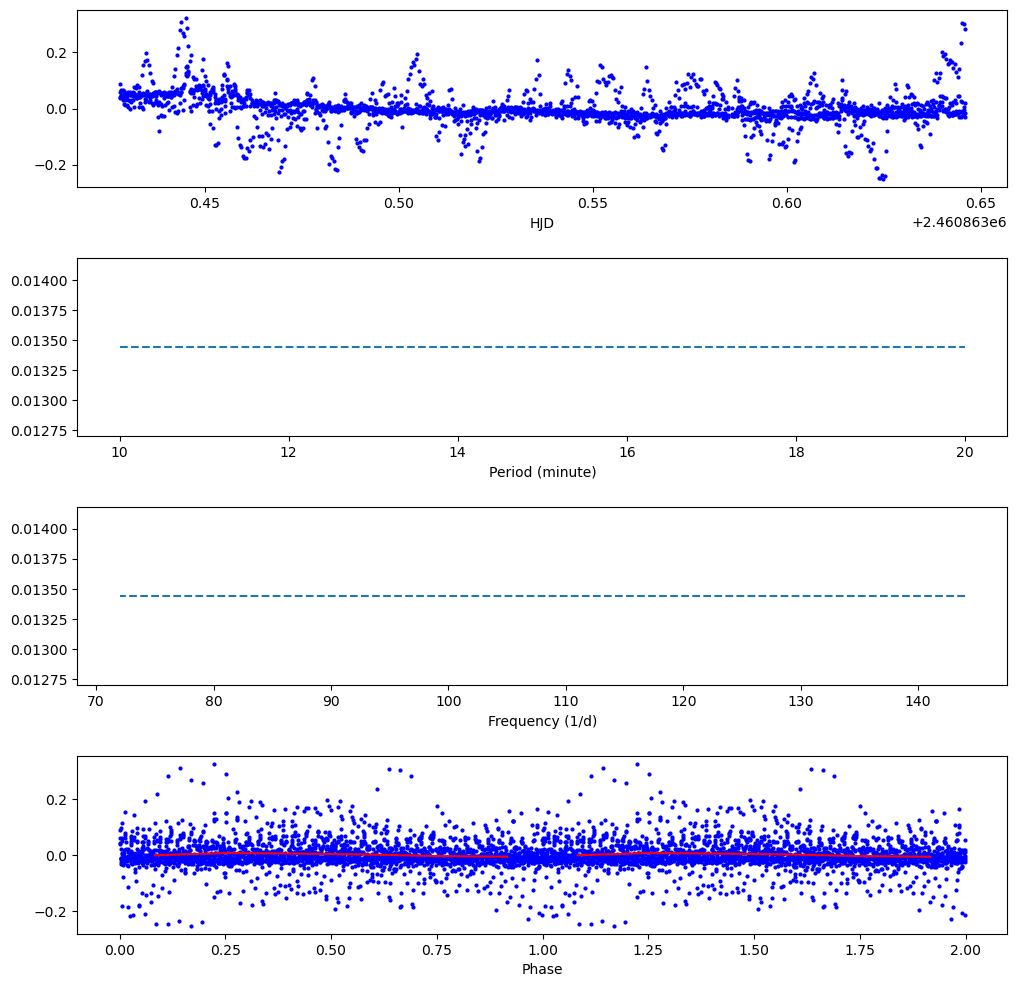

In [97]:
#### Plot

plt.close('all')

f, ax = plt.subplots(4, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(frequency,power)
ax[2].set_xlabel('Frequency (1/d)')
xmin=1./p1
xmax=1./p2
# ax[2].plot(1./frequency,power)
# ax[2].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[2].hlines(fap,xmin,xmax,linestyles='dashed')

ax[3].plot(phase,mag_c,'b.',markersize=4)
ax[3].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[3].plot(phase,y_fit,'g.',markersize=4)
ax[3].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[3].plot(center_bin,bin_means,'r-',markersize=4)
ax[3].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[3].set_xlabel('Phase')
# ax[3].set_xlim(0,2)
#ax[3].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()